Model: gpt-5.6
Total test cases: 10

BASELINE
Simple context and question instruction.

ROLE_ASSIGNMENT
Adds a role defining the model as a careful QA assistant.

OUTPUT_FORMAT
Adds an explicit Answer format.

REASONING_INSTRUCTION
Asks the model to verify the context before answering.

FEW_SHOT
Adds examples demonstrating desired behavior.

NEGATIVE_CONSTRAINTS
Prevents guessing and unsupported information.

Running: baseline
Case 1: ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to contin
Case 2: ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to contin
Case 3: ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to contin
Case 4: ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to contin
Case 5: ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to contin
Case 6: ERROR: Error cod

,version,case_id,question,reference_answer,model_answer
0,baseline,1,When was the Solar Research Institute founded?,2012,ERROR: Error code: 429 - {'error': {'message':...
1,baseline,2,What was the initial budget of Project Aurora?,$2 million,ERROR: Error code: 429 - {'error': {'message':...
2,baseline,3,What was the maximum range of the first electr...,320 kilometers,ERROR: Error code: 429 - {'error': {'message':...
3,baseline,4,Who receives free digital access?,Registered students,ERROR: Error code: 429 - {'error': {'message':...
4,baseline,5,How many engineers are on the research team?,5,ERROR: Error code: 429 - {'error': {'message':...
5,baseline,6,Which three measurements does Aqua record?,"temperature, pH, dissolved oxygen",ERROR: Error code: 429 - {'error': {'message':...
6,baseline,7,When is the technology conference held?,every October,ERROR: Error code: 429 - {'error': {'message':...
7,baseline,8,Which language was used for the backend?,Python,ERROR: Error code: 429 - {'error': {'message':...
8,baseline,9,On what date did the rover complete its first ...,"January 14, 2024",ERROR: Error code: 429 - {'error': {'message':...
9,baseline,10,How much money does the scholarship provide ea...,"₹40,000",ERROR: Error code: 429 - {'error': {'message':...



PER INPUT RESULTS


,version,case_id,accuracy,format_consistency,combined_score
0,baseline,1,1,5,3.0
1,baseline,2,1,5,3.0
2,baseline,3,1,5,3.0
3,baseline,4,1,5,3.0
4,baseline,5,1,5,3.0
5,baseline,6,1,5,3.0
6,baseline,7,1,5,3.0
7,baseline,8,1,5,3.0
8,baseline,9,1,5,3.0
9,baseline,10,1,5,3.0



PROMPT COMPARISON


,version,accuracy,format_consistency,average_score,improvement_vs_baseline
0,baseline,1.0,5.0,3.0,0.0
1,few_shot,1.0,5.0,3.0,0.0
5,role_assignment,1.0,5.0,3.0,0.0
4,reasoning_instruction,1.0,5.0,3.0,0.0
3,output_format,1.0,2.0,1.5,-1.5
2,negative_constraints,1.0,2.0,1.5,-1.5



PROMPT VERSION DICTIONARY
{
    "baseline": {
        "average_score": 3.0,
        "change": "Baseline prompt with no additional technique."
    },
    "role_assignment": {
        "average_score": 3.0,
        "change": "Added a role defining the model as a careful QA assistant."
    },
    "output_format": {
        "average_score": 1.5,
        "change": "Added explicit Answer format."
    },
    "reasoning_instruction": {
        "average_score": 3.0,
        "change": "Added context verification before producing the final answer."
    },
    "few_shot": {
        "average_score": 3.0,
        "change": "Added two examples showing the desired QA behavior."
    },
    "negative_constraints": {
        "average_score": 1.5,
        "change": "Added rules against guessing and unsupported information."
    }
}

BEST TECHNIQUE
Best technique: baseline
Average score: 3.0
Baseline score: 3.0
Improvement: 0.0

BEST TECHNIQUE HYPOTHESIS:
No hypothesis available.


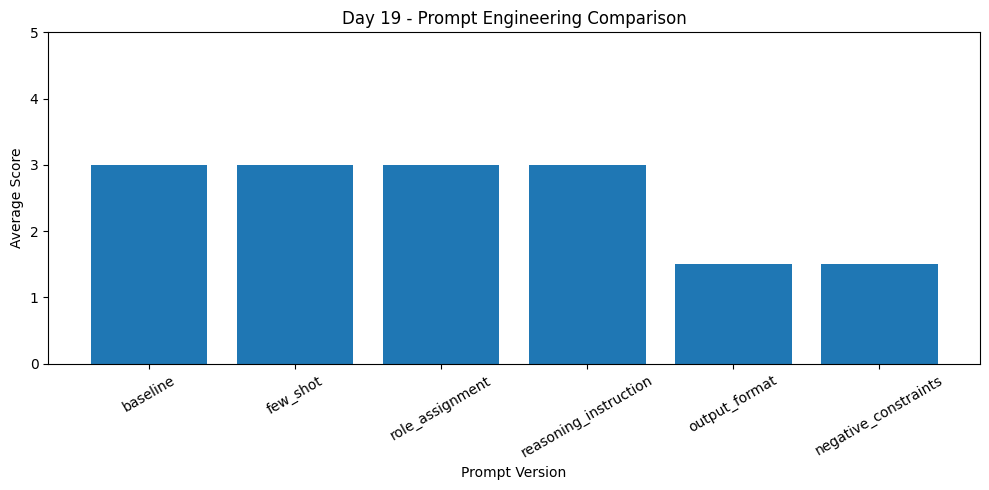


GROUNDING TEST RESULTS


,test_id,question,model_answer,refused_correctly
0,1,Who is the president of the University Technol...,ERROR: Error code: 429 - {'error': {'message':...,False
1,2,What is the club president's age?,ERROR: Error code: 429 - {'error': {'message':...,False
2,3,Which programming language is the club preside...,ERROR: Error code: 429 - {'error': {'message':...,False
3,4,How much money does the club spend every year?,ERROR: Error code: 429 - {'error': {'message':...,False
4,5,Who founded the University Technology Club?,ERROR: Error code: 429 - {'error': {'message':...,False



Grounding refusal accuracy: 0.0%


RateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

In [ ]:

# ============================================================
# DAY 19 · AI
# Prompt Engineering for Reliable LLM Outputs
# ============================================================

# Install:
# !pip install -q --upgrade openai pandas matplotlib

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI


# ============================================================
# 1. API KEY
# ============================================================

# OPTION 1: Colab
# Add OPENAI_API_KEY to Colab Secrets, then uncomment:

# from google.colab import userdata
# API_KEY = userdata.get("OPENAI_API_KEY")

# OPTION 2: Directly from environment
API_KEY = os.getenv("OPENAI_API_KEY")

# If API key is not found, ask for it
if not API_KEY:
    from getpass import getpass
    API_KEY = getpass("Enter your OpenAI API key: ")

client = OpenAI(api_key=API_KEY)


# ============================================================
# 2. MODEL
# ============================================================

MODEL = "gpt-5.6"

print("Model:", MODEL)


# ============================================================
# 3. TASK
# ============================================================

"""
Task:
Context-grounded Question Answering

The model must answer questions using only the
provided context.
"""


# ============================================================
# 4. 10 DIVERSE TEST INPUTS
# ============================================================

test_cases = [

    {
        "id": 1,
        "context": """
        The Solar Research Institute was founded in 2012.
        Its headquarters are located in Jaipur.
        The institute focuses on renewable-energy research.
        """,
        "question": "When was the Solar Research Institute founded?",
        "reference_answer": "2012"
    },

    {
        "id": 2,
        "context": """
        Project Aurora began in March 2021 with a budget of
        $2 million. The project was designed to improve
        urban transportation systems.
        """,
        "question": "What was the initial budget of Project Aurora?",
        "reference_answer": "$2 million"
    },

    {
        "id": 3,
        "context": """
        The company introduced its first electric vehicle in 2018.
        The vehicle had a maximum range of 320 kilometers.
        """,
        "question": "What was the maximum range of the first electric vehicle?",
        "reference_answer": "320 kilometers"
    },

    {
        "id": 4,
        "context": """
        The Green Library opened in 2019.
        It contains more than 50,000 books and provides
        free digital access to registered students.
        """,
        "question": "Who receives free digital access?",
        "reference_answer": "Registered students"
    },

    {
        "id": 5,
        "context": """
        The research team consists of 12 scientists,
        5 engineers, and 3 data analysts.
        """,
        "question": "How many engineers are on the research team?",
        "reference_answer": "5"
    },

    {
        "id": 6,
        "context": """
        The Aqua project uses sensors to monitor water quality.
        It records temperature, pH, and dissolved oxygen levels.
        """,
        "question": "Which three measurements does Aqua record?",
        "reference_answer": "temperature, pH, dissolved oxygen"
    },

    {
        "id": 7,
        "context": """
        The annual technology conference is held every October.
        In 2025, it was hosted in Bengaluru.
        """,
        "question": "When is the technology conference held?",
        "reference_answer": "every October"
    },

    {
        "id": 8,
        "context": """
        The mobile application was developed using Python
        for the backend and JavaScript for the frontend.
        """,
        "question": "Which language was used for the backend?",
        "reference_answer": "Python"
    },

    {
        "id": 9,
        "context": """
        The Mars rover completed its first successful communication
        test on January 14, 2024.
        """,
        "question": "On what date did the rover complete its first successful communication test?",
        "reference_answer": "January 14, 2024"
    },

    {
        "id": 10,
        "context": """
        The scholarship provides students with ₹40,000 per year
        and covers tuition fees for three years.
        """,
        "question": "How much money does the scholarship provide each year?",
        "reference_answer": "₹40,000"
    }
]

print("Total test cases:", len(test_cases))


# ============================================================
# 5. OPENAI API FUNCTION
# ============================================================

def ask_model(prompt):

    response = client.responses.create(
        model=MODEL,
        input=prompt
    )

    return response.output_text.strip()


# ============================================================
# 6. PROMPT VERSIONS
# ============================================================

PROMPTS = {

    # ---------------- BASELINE ----------------

    "baseline": {
        "description":
            "Simple context and question instruction.",

        "prompt": """
Answer the question using the context.

Context:
{context}

Question:
{question}
"""
    },


    # ---------------- ROLE ASSIGNMENT ----------------

    "role_assignment": {
        "description":
            "Adds a role defining the model as a careful QA assistant.",

        "prompt": """
You are a careful question-answering assistant.

Answer the question using the context.

Context:
{context}

Question:
{question}
"""
    },


    # ---------------- OUTPUT FORMAT ----------------

    "output_format": {
        "description":
            "Adds an explicit Answer format.",

        "prompt": """
Answer the question using the context.

Return exactly:

Answer: <short answer>

Do not add unnecessary information.

Context:
{context}

Question:
{question}
"""
    },


    # ---------------- REASONING INSTRUCTION ----------------

    "reasoning_instruction": {
        "description":
            "Asks the model to verify the context before answering.",

        "prompt": """
You are a careful question-answering assistant.

Before answering, carefully verify the relevant information
in the provided context.

Do not rely on outside knowledge.

Return only the final answer.

Context:
{context}

Question:
{question}
"""
    },


    # ---------------- FEW SHOT ----------------

    "few_shot": {
        "description":
            "Adds examples demonstrating desired behavior.",

        "prompt": """
You are a context-based question-answering assistant.

Example 1:

Context:
The library opened in 2020 and contains 10,000 books.

Question:
When did the library open?

Answer:
2020


Example 2:

Context:
The project has 8 engineers and 4 designers.

Question:
How many engineers are there?

Answer:
8


Now answer the following question.

Context:
{context}

Question:
{question}

Answer:
"""
    },


    # ---------------- NEGATIVE CONSTRAINTS ----------------

    "negative_constraints": {
        "description":
            "Prevents guessing and unsupported information.",

        "prompt": """
You are a careful context-based question-answering assistant.

Rules:

- Use only information contained in the context.
- Do not use outside knowledge.
- Do not guess.
- Do not invent missing information.
- Give a concise answer.
- If the answer is not supported by the context, say:
  "Not supported by the provided context."

Context:
{context}

Question:
{question}

Answer:
"""
    }
}


# ============================================================
# 7. DISPLAY PROMPT VERSIONS
# ============================================================

for name, data in PROMPTS.items():

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    print(data["description"])


# ============================================================
# 8. RUN ALL PROMPTS ON SAME 10 INPUTS
# ============================================================

results = []

for version_name, version_data in PROMPTS.items():

    print("\nRunning:", version_name)

    for case in test_cases:

        prompt = version_data["prompt"].format(
            context=case["context"],
            question=case["question"]
        )

        try:

            answer = ask_model(prompt)

        except Exception as e:

            answer = "ERROR: " + str(e)

        results.append({

            "version": version_name,

            "case_id": case["id"],

            "question": case["question"],

            "reference_answer":
                case["reference_answer"],

            "model_answer":
                answer
        })

        print(
            f"Case {case['id']}: "
            f"{answer[:100]}"
        )


# ============================================================
# 9. DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\nResults:")
display(results_df)


# ============================================================
# 10. TEXT NORMALIZATION
# ============================================================

def normalize_text(text):

    text = str(text).lower().strip()

    text = text.replace("answer:", "")
    text = text.replace("**", "")
    text = text.replace(".", "")
    text = text.replace(",", "")

    return " ".join(text.split())


# ============================================================
# 11. ACCURACY SCORE 1–5
# ============================================================

def accuracy_score(model_answer, reference_answer):

    model_clean = normalize_text(model_answer)
    reference_clean = normalize_text(reference_answer)

    # Exact reference contained in answer
    if reference_clean in model_clean:
        return 5

    # Partial matching
    reference_words = set(reference_clean.split())
    model_words = set(model_clean.split())

    if len(reference_words) > 0:

        overlap = (
            len(reference_words & model_words)
            / len(reference_words)
        )

        if overlap >= 0.5:
            return 3

    return 1


results_df["accuracy"] = results_df.apply(
    lambda row: accuracy_score(
        row["model_answer"],
        row["reference_answer"]
    ),
    axis=1
)


# ============================================================
# 12. FORMAT CONSISTENCY SCORE 1–5
# ============================================================

def format_score(version, answer):

    answer = str(answer).strip()

    if not answer:
        return 1

    # Explicit format prompts
    if version in [
        "output_format",
        "negative_constraints"
    ]:

        if answer.lower().startswith("answer:"):
            return 5

        return 2

    # Concise answers
    word_count = len(answer.split())

    if word_count <= 30:
        return 5

    elif word_count <= 50:
        return 3

    else:
        return 1


results_df["format_consistency"] = results_df.apply(
    lambda row: format_score(
        row["version"],
        row["model_answer"]
    ),
    axis=1
)


# ============================================================
# 13. COMBINED SCORE
# ============================================================

results_df["combined_score"] = (
    results_df["accuracy"]
    +
    results_df["format_consistency"]
) / 2


# ============================================================
# 14. PER-INPUT RESULTS
# ============================================================

print("\nPER INPUT RESULTS")

display(
    results_df[
        [
            "version",
            "case_id",
            "accuracy",
            "format_consistency",
            "combined_score"
        ]
    ]
)


# ============================================================
# 15. AVERAGE SCORE FOR EACH PROMPT
# ============================================================

summary = (

    results_df

    .groupby("version")

    .agg(

        accuracy=("accuracy", "mean"),

        format_consistency=(
            "format_consistency",
            "mean"
        ),

        average_score=(
            "combined_score",
            "mean"
        )
    )

    .reset_index()
)


# ============================================================
# 16. BASELINE SCORE
# ============================================================

baseline_score = summary.loc[
    summary["version"] == "baseline",
    "average_score"
].iloc[0]


# ============================================================
# 17. IMPROVEMENT VS BASELINE
# ============================================================

summary["improvement_vs_baseline"] = (
    summary["average_score"]
    - baseline_score
)


summary = summary.sort_values(
    "average_score",
    ascending=False
)


print("\nPROMPT COMPARISON")

display(summary)


# ============================================================
# 18. PROMPT VERSION DICTIONARY
# ============================================================

prompt_version_dictionary = {

    "baseline": {
        "average_score": None,
        "change":
            "Baseline prompt with no additional technique."
    },

    "role_assignment": {
        "average_score": None,
        "change":
            "Added a role defining the model as a careful QA assistant."
    },

    "output_format": {
        "average_score": None,
        "change":
            "Added explicit Answer format."
    },

    "reasoning_instruction": {
        "average_score": None,
        "change":
            "Added context verification before producing the final answer."
    },

    "few_shot": {
        "average_score": None,
        "change":
            "Added two examples showing the desired QA behavior."
    },

    "negative_constraints": {
        "average_score": None,
        "change":
            "Added rules against guessing and unsupported information."
    }
}


# Fill measured scores

for version in prompt_version_dictionary:

    row = summary[
        summary["version"] == version
    ]

    if not row.empty:

        prompt_version_dictionary[
            version
        ]["average_score"] = round(
            float(row["average_score"].iloc[0]),
            2
        )


print("\nPROMPT VERSION DICTIONARY")

print(
    json.dumps(
        prompt_version_dictionary,
        indent=4
    )
)


# ============================================================
# 19. BEST TECHNIQUE
# ============================================================

best_row = summary.iloc[0]

best_version = best_row["version"]

best_score = best_row["average_score"]

improvement = (
    best_score - baseline_score
)

print("\n" + "=" * 70)
print("BEST TECHNIQUE")
print("=" * 70)

print("Best technique:", best_version)

print(
    "Average score:",
    round(best_score, 2)
)

print(
    "Baseline score:",
    round(baseline_score, 2)
)

print(
    "Improvement:",
    round(improvement, 2)
)


# ============================================================
# 20. HYPOTHESES
# ============================================================

hypotheses = {

    "role_assignment":
        "The role may improve performance by giving the model a clearer behavioral objective.",

    "output_format":
        "The explicit format may improve consistency because the model has a concrete structure to follow.",

    "reasoning_instruction":
        "The verification instruction may improve accuracy by encouraging the model to check the supplied context.",

    "few_shot":
        "Examples may improve performance because they demonstrate the desired behavior directly.",

    "negative_constraints":
        "Negative constraints may improve reliability by explicitly preventing guessing and unsupported information."
}


print("\nBEST TECHNIQUE HYPOTHESIS:")

print(
    hypotheses.get(
        best_version,
        "No hypothesis available."
    )
)


# ============================================================
# 21. GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    summary["version"],
    summary["average_score"]
)

plt.xlabel("Prompt Version")

plt.ylabel("Average Score")

plt.title(
    "Day 19 - Prompt Engineering Comparison"
)

plt.xticks(rotation=30)

plt.ylim(0, 5)

plt.tight_layout()

plt.show()


# ============================================================
# 22. GROUNDING SYSTEM PROMPT
# ============================================================

GROUNDING_SYSTEM_PROMPT = """
You are a grounded RAG question-answering assistant.

Your job is to answer questions using ONLY information
contained in the provided context.

Rules:

1. Use only information explicitly supported by the context.
2. Do not use outside knowledge.
3. Do not guess.
4. Do not infer unsupported facts.
5. If the answer is not directly supported by the context,
   refuse to answer.
6. When refusing, respond exactly:

I cannot answer this from the provided context.

7. Keep supported answers concise.
"""


# ============================================================
# 23. GROUNDING CONTEXT
# ============================================================

grounding_context = """
The University Technology Club was established in 2020.

The club has 120 registered members.

It organizes workshops on Python, web development,
and artificial intelligence.

The club meets every Saturday in the university computer lab.

Its annual technical festival is called TechNova.
"""


# ============================================================
# 24. FIVE OUT-OF-CONTEXT QUESTIONS
# ============================================================

out_of_context_questions = [

    "Who is the president of the University Technology Club?",

    "What is the club president's age?",

    "Which programming language is the club president's favorite?",

    "How much money does the club spend every year?",

    "Who founded the University Technology Club?"
]


# ============================================================
# 25. GROUNDED MODEL FUNCTION
# ============================================================

def grounded_answer(question, context):

    response = client.responses.create(

        model=MODEL,

        instructions=GROUNDING_SYSTEM_PROMPT,

        input=f"""
Context:
{context}

Question:
{question}
"""
    )

    return response.output_text.strip()


# ============================================================
# 26. RUN GROUNDING TESTS
# ============================================================

grounding_results = []


for i, question in enumerate(
    out_of_context_questions,
    start=1
):

    try:

        answer = grounded_answer(
            question,
            grounding_context
        )

    except Exception as e:

        answer = "ERROR: " + str(e)


    refused = (
        "i cannot answer this from the provided context."
        in answer.lower()
    )


    grounding_results.append({

        "test_id": i,

        "question": question,

        "model_answer": answer,

        "refused_correctly": refused
    })


# ============================================================
# 27. GROUNDING RESULTS
# ============================================================

grounding_df = pd.DataFrame(
    grounding_results
)


print("\nGROUNDING TEST RESULTS")

display(grounding_df)


# ============================================================
# 28. GROUNDING ACCURACY
# ============================================================

grounding_accuracy = (

    grounding_df[
        "refused_correctly"
    ].mean()

    * 100
)


print(
    f"\nGrounding refusal accuracy: "
    f"{grounding_accuracy:.1f}%"
)


# ============================================================
# 29. TEST SUPPORTED QUESTION
# ============================================================

supported_question = (
    "How many registered members does the club have?"
)


supported_answer = grounded_answer(
    supported_question,
    grounding_context
)


print("\nSUPPORTED QUESTION")

print(
    "Question:",
    supported_question
)

print(
    "Answer:",
    supported_answer
)


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DAY 19 FINAL SUMMARY")
print("=" * 70)

print(
    "Task: Context-grounded Question Answering"
)

print(
    "Test inputs:",
    len(test_cases)
)

print(
    "Prompt versions:",
    len(PROMPTS)
)

print(
    "Baseline score:",
    round(baseline_score, 2)
)

print(
    "Best technique:",
    best_version
)

print(
    "Best score:",
    round(best_score, 2)
)

print(
    "Improvement:",
    round(improvement, 2)
)

print(
    "Grounding accuracy:",
    f"{grounding_accuracy:.1f}%"
)


# ============================================================
# 31. EXPORT RESULTS
# ============================================================

results_df.to_csv(
    "day19_prompt_results.csv",
    index=False
)

summary.to_csv(
    "day19_prompt_summary.csv",
    index=False
)

grounding_df.to_csv(
    "day19_grounding_results.csv",
    index=False
)


with open(
    "day19_prompt_versions.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        prompt_version_dictionary,
        f,
        indent=4,
        ensure_ascii=False
    )


print("\nFiles created:")
print("1. day19_prompt_results.csv")
print("2. day19_prompt_summary.csv")
print("3. day19_grounding_results.csv")
print("4. day19_prompt_versions.json")


# ============================================================
# 32. SUBMISSION CHECKLIST
# ============================================================

print("\n" + "=" * 70)
print("SUBMISSION CHECKLIST")
print("=" * 70)

checklist = [

    ("10 diverse inputs", len(test_cases) == 10),

    ("Baseline prompt", "baseline" in PROMPTS),

    ("Role assignment", "role_assignment" in PROMPTS),

    ("Output format", "output_format" in PROMPTS),

    ("Reasoning instruction",
     "reasoning_instruction" in PROMPTS),

    ("Few-shot examples",
     "few_shot" in PROMPTS),

    ("Negative constraints",
     "negative_constraints" in PROMPTS),

    ("Prompt version dictionary",
     len(prompt_version_dictionary) == 6),

    ("Best technique identified",
     best_version is not None),

    ("Five grounding tests",
     len(grounding_df) == 5),

    ("Results exported",
     os.path.exists("day19_prompt_results.csv"))
]


for name, status in checklist:

    print(
        ("PASS" if status else "FAIL"),
        "-",
        name
    )


# ============================================================
# END OF DAY 19
# ============================================================